In [1]:
import os
import sys

sys.stderr = open(os.devnull, "w")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from tqdm import tqdm
from dateutil.relativedelta import relativedelta
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

warnings.filterwarnings('ignore', category=FutureWarning)

np.random.seed(42)

In [2]:
sales = pd.read_csv('pedidos.csv', sep=';')

In [3]:
df_count = sales[['account_id', 'sales_channel_id']].value_counts()
df_count = pd.DataFrame(df_count).reset_index()

In [4]:
ALL_SALES_CHANNELS = True
LOOKBACK = 3
CRIT_VALUE = 0.25
END_DATE = pd.to_datetime(pd.to_datetime(sales['created_date'].max()).strftime("%Y-%m-%d %H:00:00"))
START_DATE = END_DATE - timedelta(hours=END_DATE.hour)
TEST_SIZE = int((END_DATE - START_DATE).seconds / 60**2 + 1)

In [5]:
OOT_DATE = START_DATE + timedelta(hours=23)

In [6]:
OOT_PERIODS = int((OOT_DATE - END_DATE).seconds / 60**2 + 1)

In [7]:
oot_dates = pd.DatetimeIndex([END_DATE+timedelta(hours=h) for h in range(1, OOT_PERIODS)], freq='h')
df_oot = pd.DataFrame(index=oot_dates)

Processing account_id: 5dd8b3ee-6f1c-4ac9-bbc5-91829dde38eb, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3181.138
train MAE:  1765.218
test RMSE: 1229.735
test MAE:  905.153


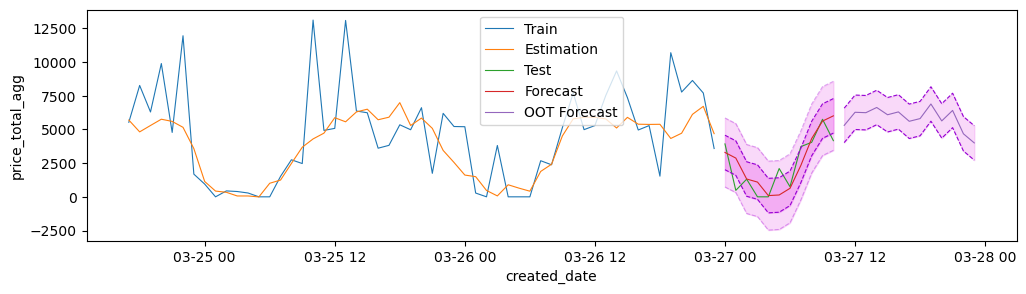

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5.940
train MAE:  3.532
test RMSE: 3.174
test MAE:  2.284


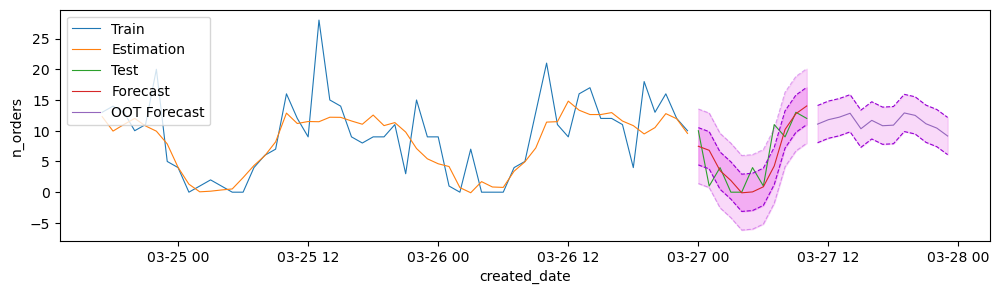

Processing account_id: 7412074f-0f3a-4724-b035-7fb4db3174c8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2741.233
train MAE:  678.630
test RMSE: 3.772
test MAE:  3.772


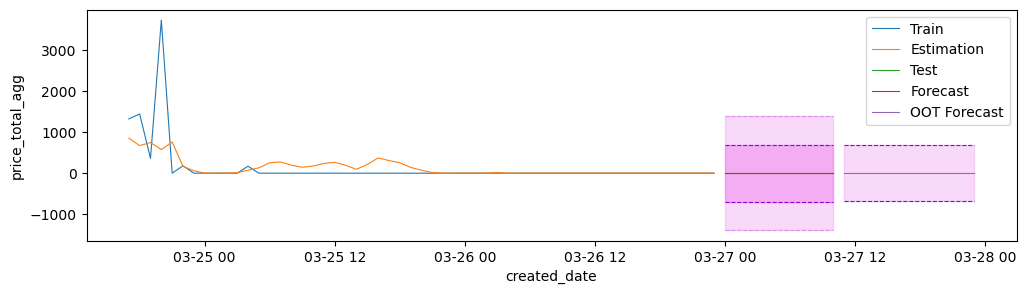

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.359
train MAE:  1.207
test RMSE: 0.001
test MAE:  0.001


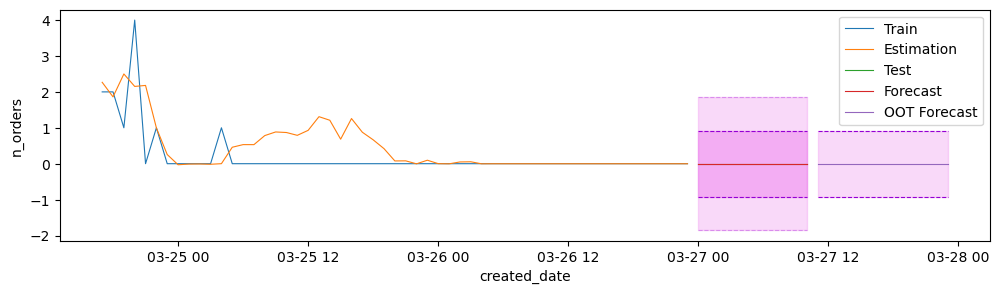

Processing account_id: 9d1296ca-9e4f-4840-b7b5-e12172acab78, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 702.394
train MAE:  244.512
test RMSE: 29.319
test MAE:  8.840


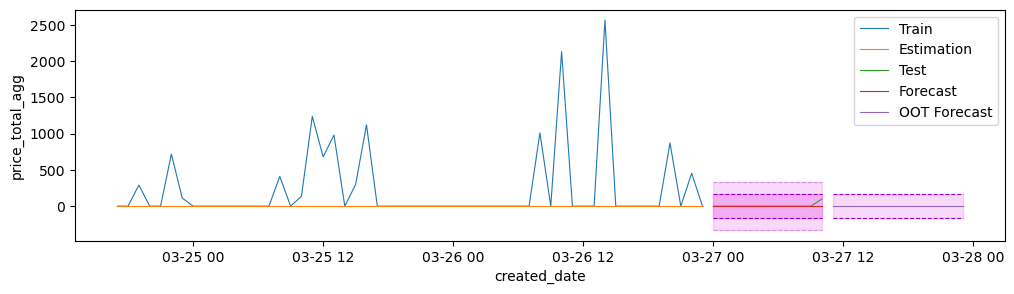

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.193
train MAE:  0.955
test RMSE: 0.302
test MAE:  0.091


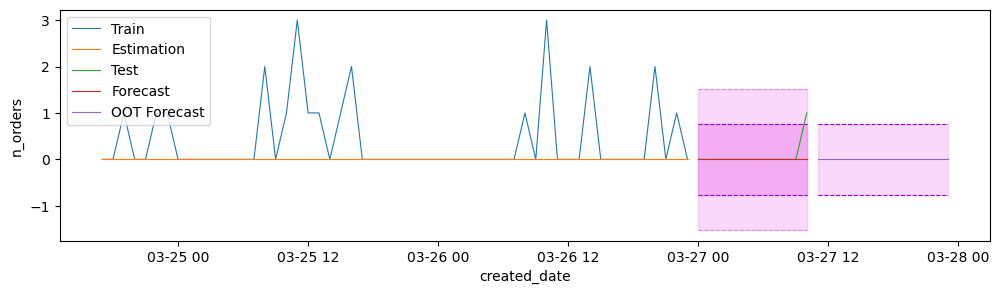

Processing account_id: 60c8f748-e29d-4fce-9e66-584117ca2baf, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2408.514
train MAE:  1220.792
test RMSE: 1722.287
test MAE:  1304.438


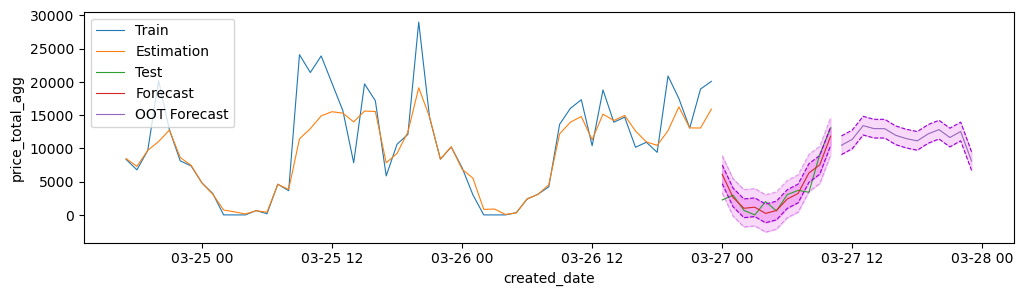

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.280
train MAE:  1.592
test RMSE: 4.255
test MAE:  3.618


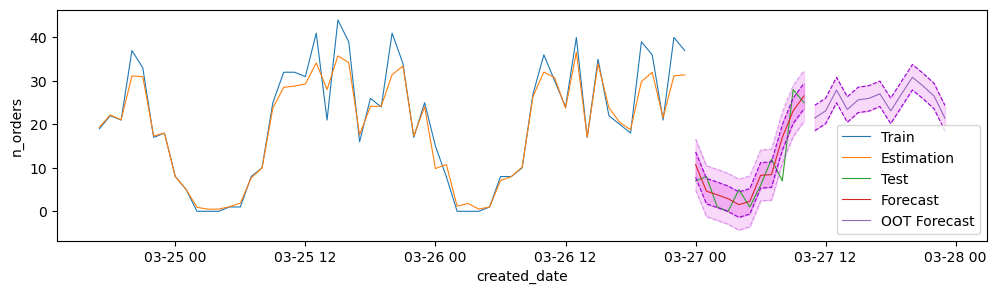

Processing account_id: ad942d1a-15ab-4a0d-83a8-ae82183ece53, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 558.343
train MAE:  361.998
test RMSE: 582.499
test MAE:  324.721


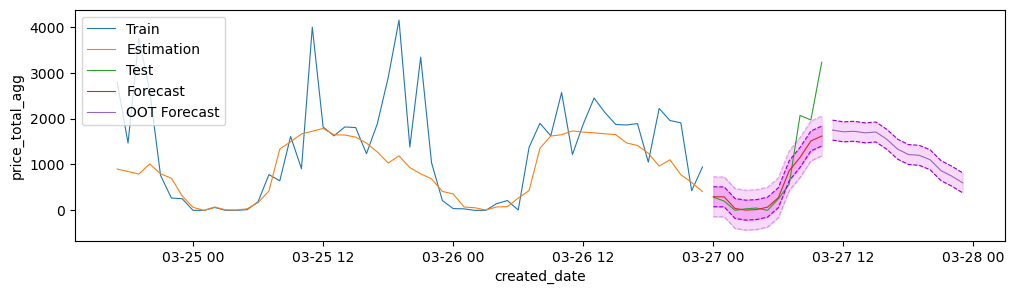

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.897
train MAE:  1.982
test RMSE: 1.756
test MAE:  1.152


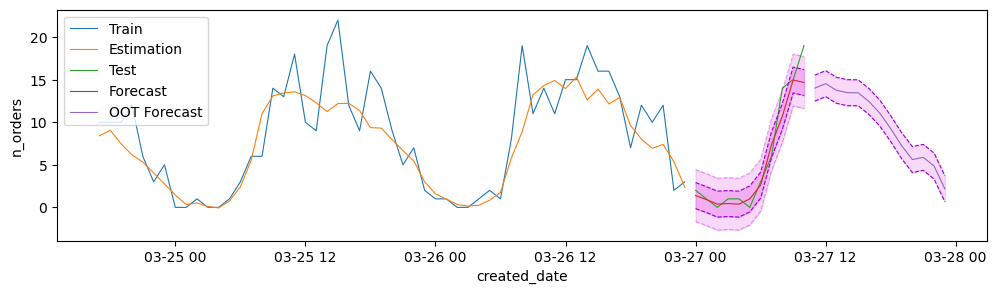

Processing account_id: 60ca8452-5b14-481f-a637-8756f527aee8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1354.868
train MAE:  248.057
test RMSE: 0.000
test MAE:  0.000


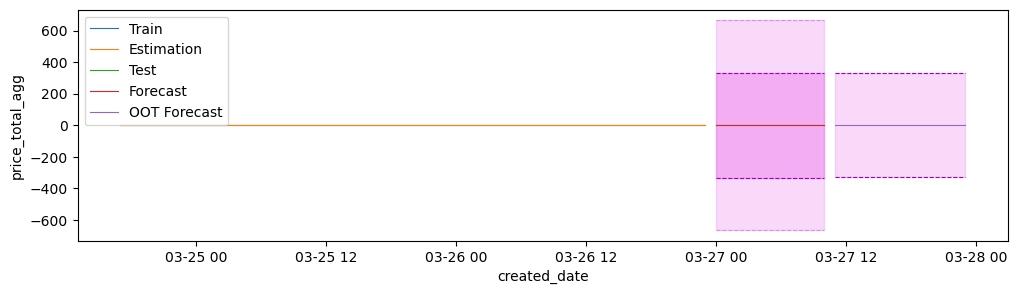

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 6.634
train MAE:  1.257
test RMSE: 0.000
test MAE:  0.000


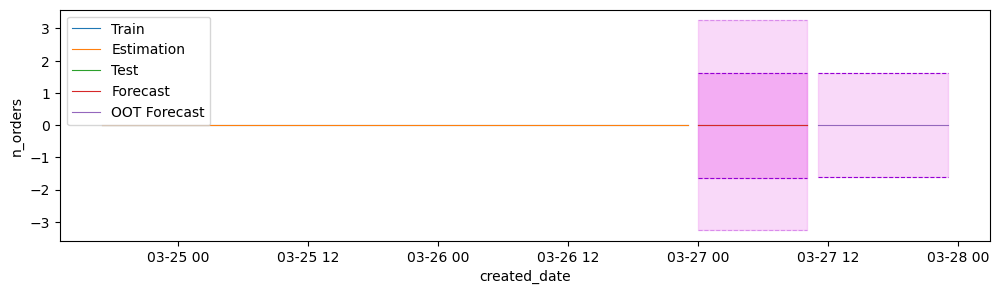

Processing account_id: 0661e926-f219-456e-bde5-612fee6f891c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1103.822
train MAE:  389.891
test RMSE: 333.049
test MAE:  251.684


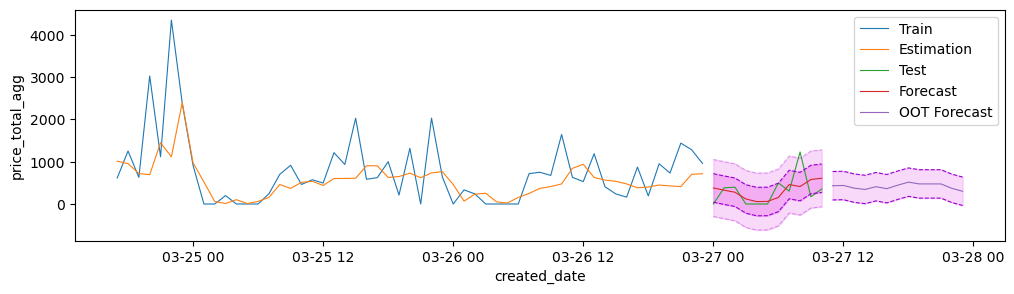

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 6.901
train MAE:  1.723
test RMSE: 1.173
test MAE:  0.962


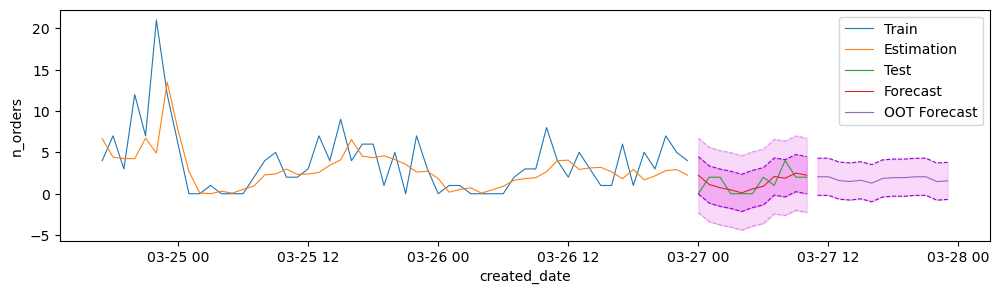

Processing account_id: ca35e88d-d191-4722-b90c-92f4a249869b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 805.149
train MAE:  444.060
test RMSE: 411.313
test MAE:  243.874


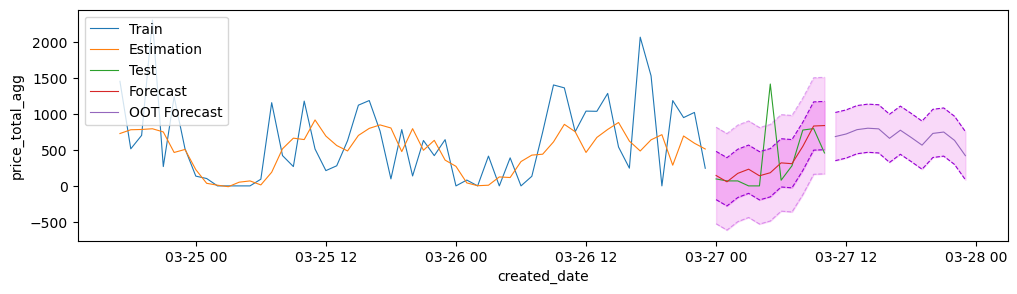

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.238
train MAE:  1.901
test RMSE: 1.712
test MAE:  1.299


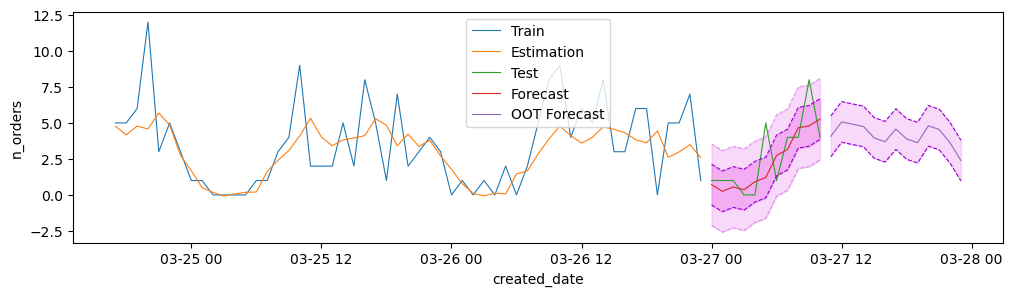

Processing account_id: f9129295-bb08-4330-b60c-9f0beadda521, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 78843.397
train MAE:  30375.911
test RMSE: 36095.279
test MAE:  30902.686


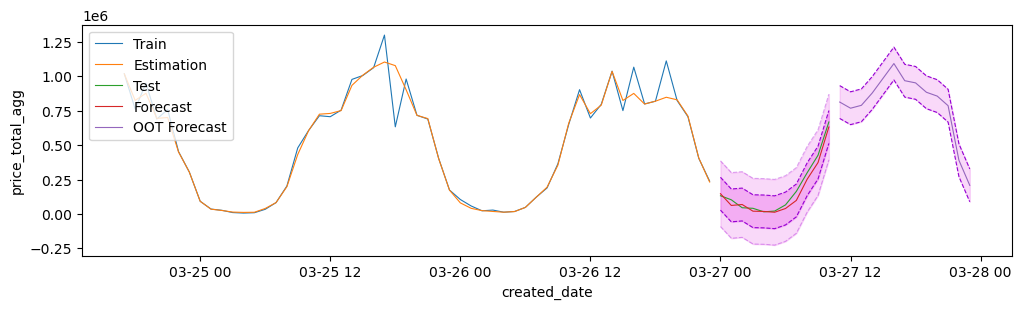

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 17.501
train MAE:  7.747
test RMSE: 16.302
test MAE:  10.174


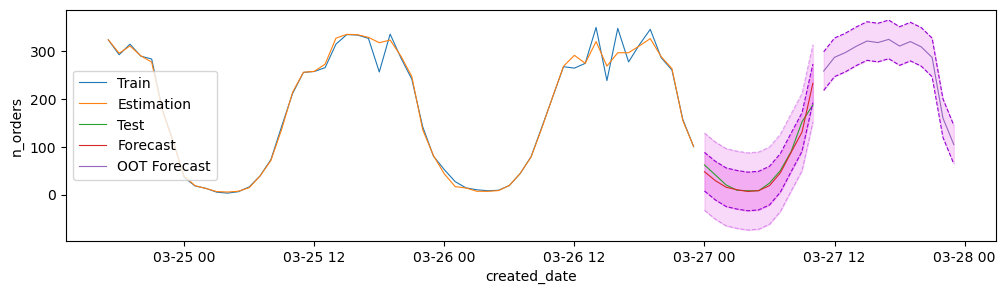

Processing account_id: 6cd2fa8a-5bac-4cc0-b4df-bd2c7d29e71b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 250.991
train MAE:  138.690
test RMSE: 0.000
test MAE:  0.000


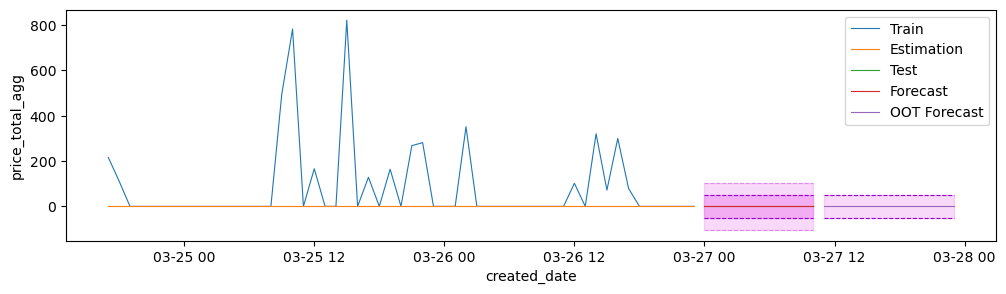

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.147
train MAE:  0.666
test RMSE: 0.000
test MAE:  0.000


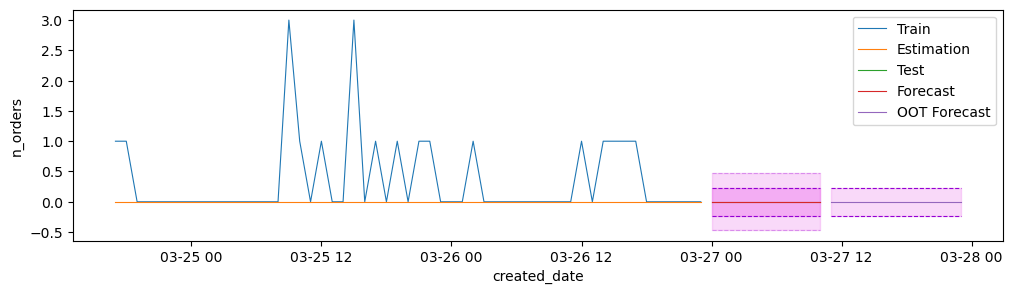

Processing account_id: 8fa00df1-38eb-426f-81a6-1185983e14cb, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 424.250
train MAE:  73.257
test RMSE: 0.000
test MAE:  0.000


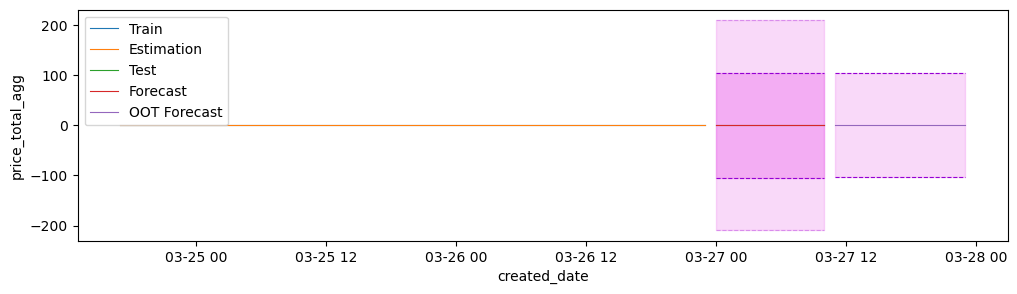

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 7.118
train MAE:  1.183
test RMSE: 0.000
test MAE:  0.000


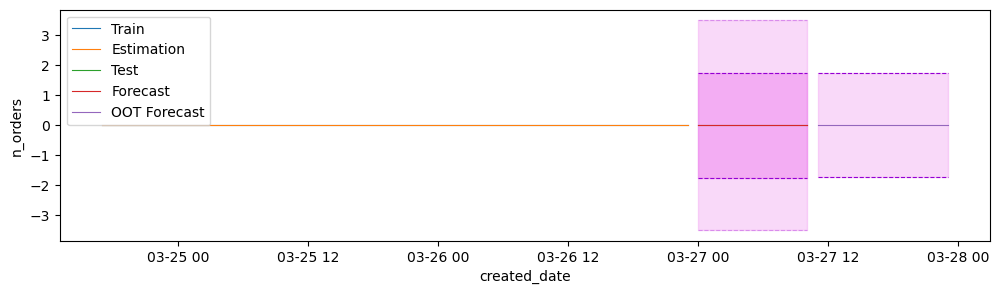

Processing account_id: 423a069b-27b8-44ed-9ef3-ca3cf9470970, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 31145.681
train MAE:  1020.274
test RMSE: 6945.292
test MAE:  2164.897


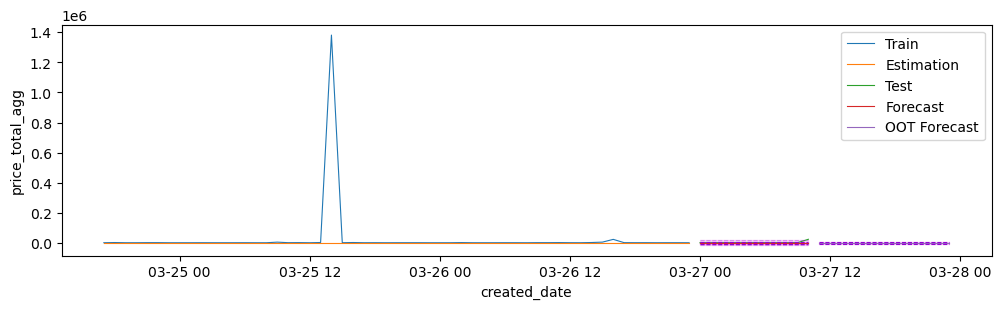

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 825.756
train MAE:  22.480
test RMSE: 2.594
test MAE:  1.636


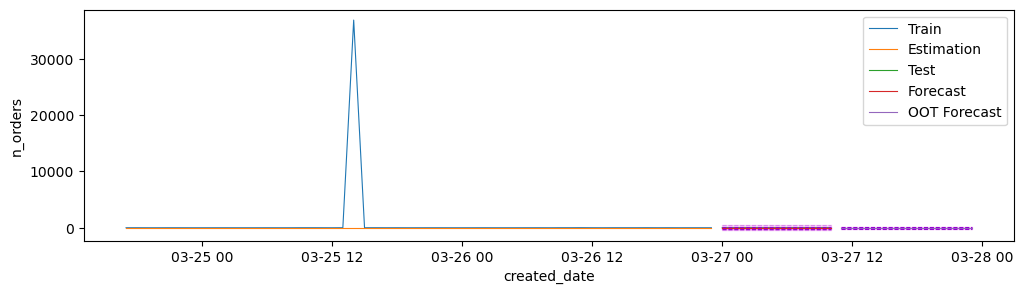

Processing account_id: 789ff5c4-21d8-4ed3-ab64-8b46cf2eba9b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 665.805
train MAE:  195.866
test RMSE: 101.360
test MAE:  88.608


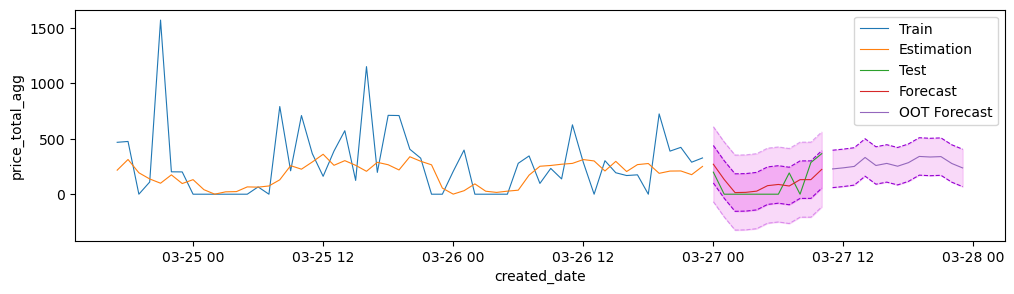

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 9.037
train MAE:  1.530
test RMSE: 0.887
test MAE:  0.621


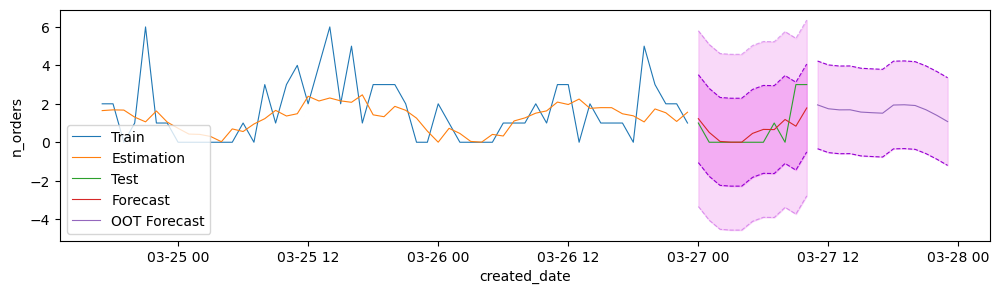

Processing account_id: 3dc15e4b-b60d-4c49-aae8-97cf9664af51, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 217.360
train MAE:  37.642
test RMSE: 4.731
test MAE:  1.426


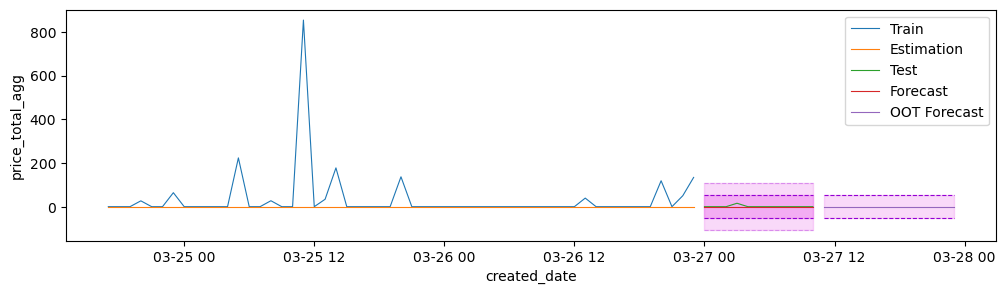

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.938
train MAE:  0.444
test RMSE: 0.302
test MAE:  0.091


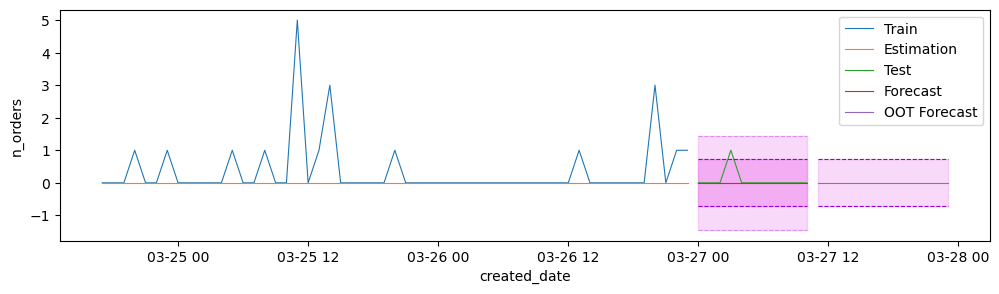

Processing account_id: e2de40dd-743b-4105-9077-3f343fea980d, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1979.498
train MAE:  1080.984
test RMSE: 1761.444
test MAE:  1319.367


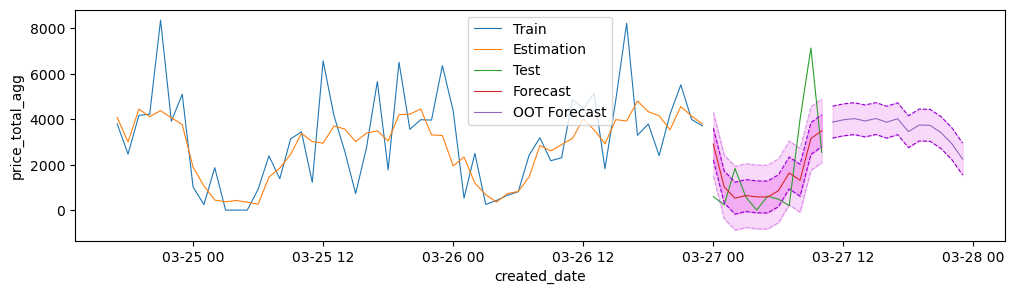

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 5.178
train MAE:  3.113
test RMSE: 2.581
test MAE:  2.171


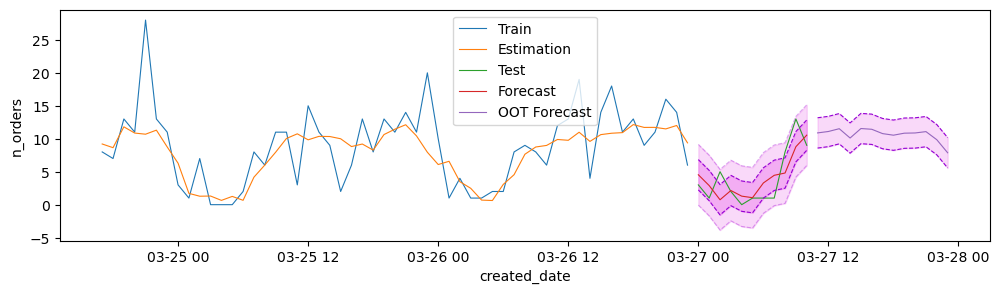

Processing account_id: 6276b87c-ebb2-11ed-a05b-0242ac120003, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 363.266
train MAE:  219.371
test RMSE: 210.333
test MAE:  152.645


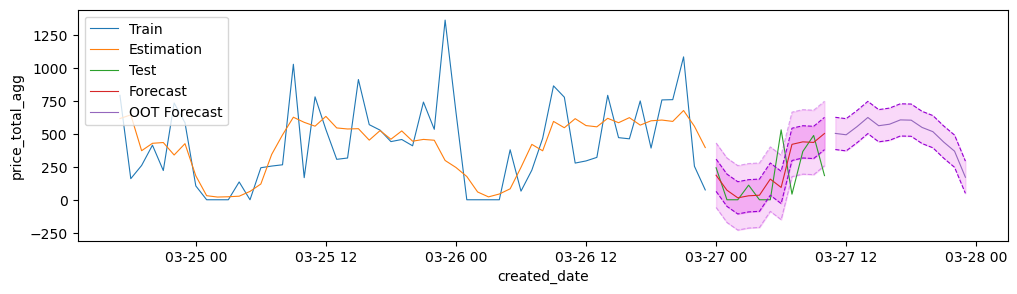

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.542
train MAE:  1.687
test RMSE: 1.217
test MAE:  0.941


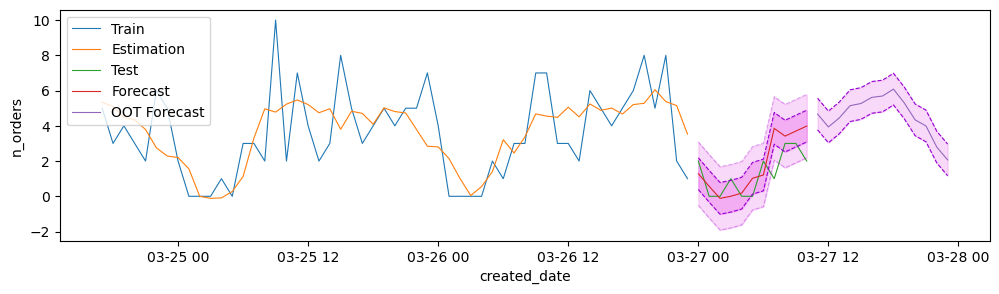

Processing account_id: 775dcad4-0733-4c22-8dbd-cd3ce344e891, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1011.022
train MAE:  618.507
test RMSE: 752.792
test MAE:  482.302


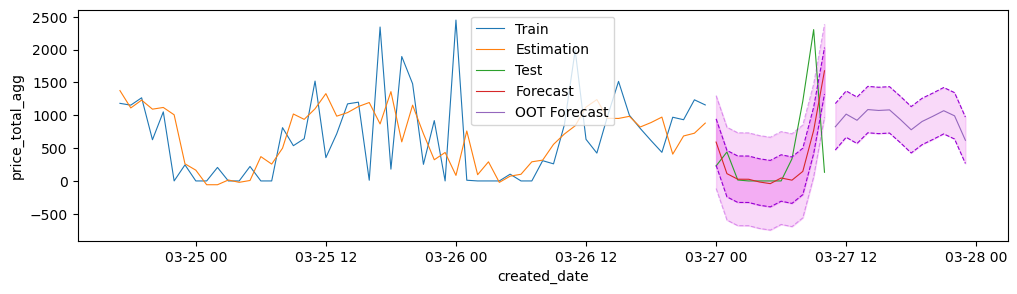

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.763
train MAE:  1.631
test RMSE: 1.916
test MAE:  1.218


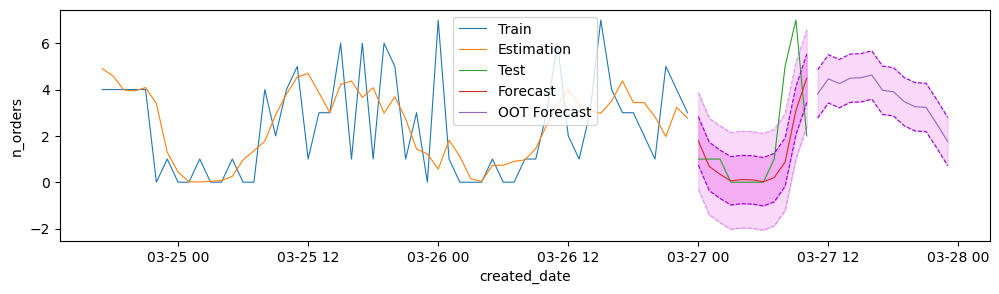

Processing account_id: 5f5ed10c-7792-4080-970c-b11398e3f58f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


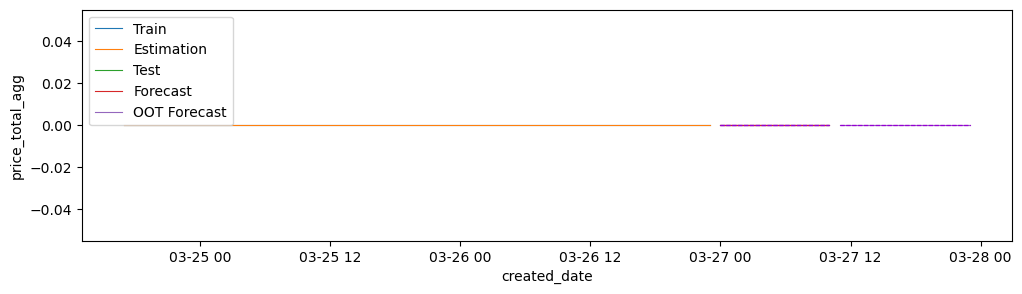

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


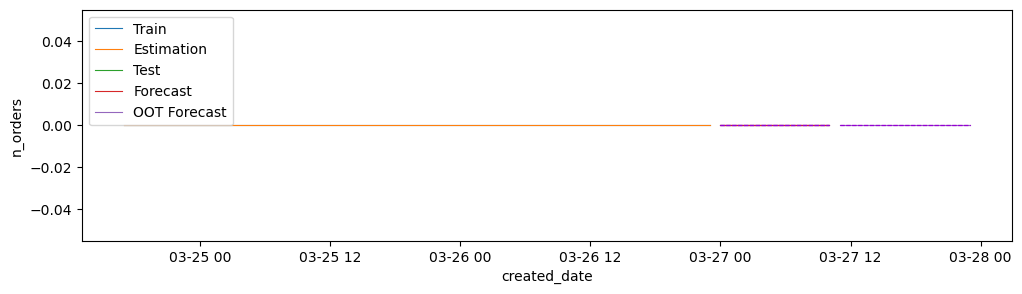

Processing account_id: 50409b57-b000-43d5-9358-44c3081c4132, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 643.865
train MAE:  267.128
test RMSE: 161.021
test MAE:  90.493


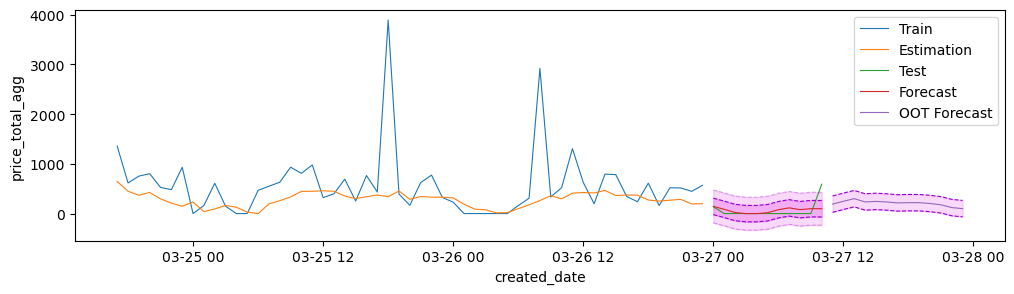

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.758
train MAE:  0.843
test RMSE: 0.862
test MAE:  0.350


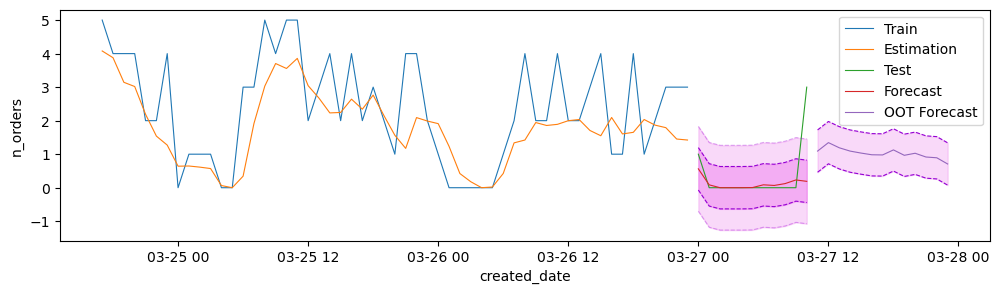

Processing account_id: c0cc925b-66c1-4b1c-b609-1bddc82ef4a4, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 94.076
train MAE:  28.574
test RMSE: 0.000
test MAE:  0.000


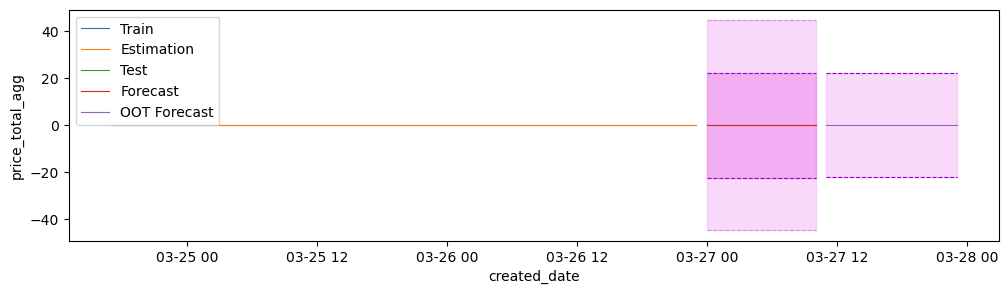

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.560
train MAE:  0.206
test RMSE: 0.000
test MAE:  0.000


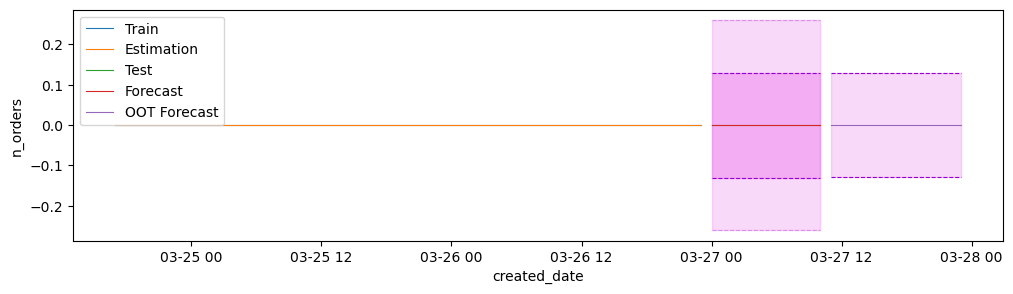

Processing account_id: 457bce7b-9300-4c10-9a97-070b3c0d081d, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2564.683
train MAE:  1268.598
test RMSE: 5205.848
test MAE:  2031.312


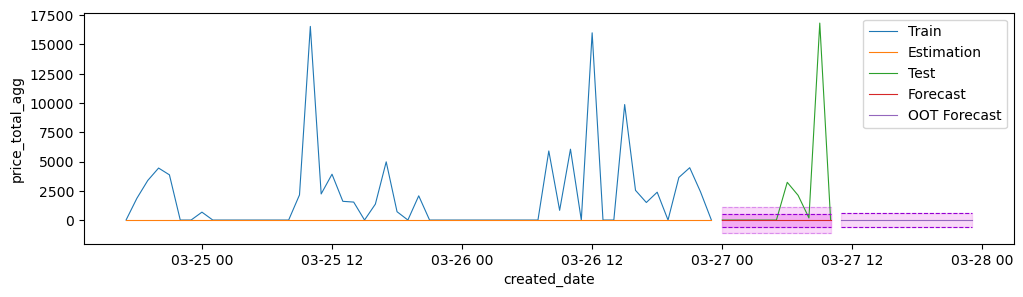

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.128
train MAE:  0.621
test RMSE: 0.953
test MAE:  0.545


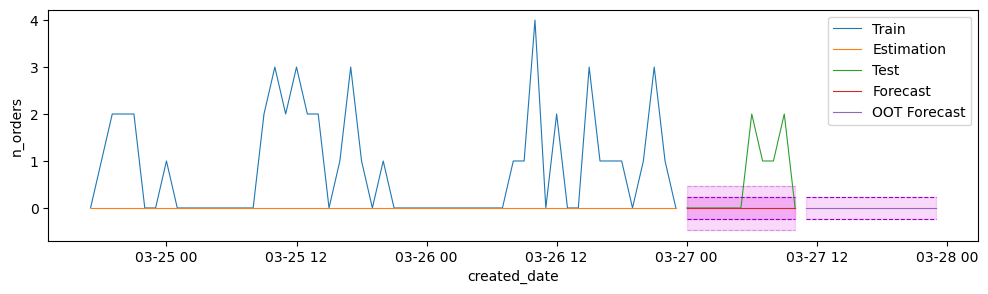

Processing account_id: 173e2b27-8bc6-44d1-b581-a1913d6b1894, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1927.134
train MAE:  990.155
test RMSE: 1749.272
test MAE:  1093.409


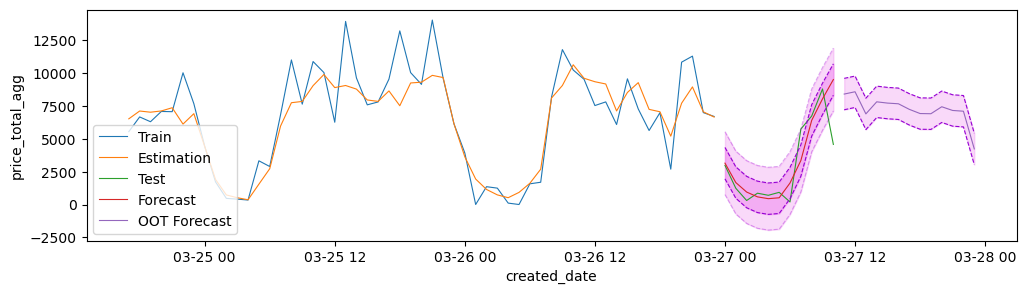

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4.960
train MAE:  2.737
test RMSE: 3.560
test MAE:  2.170


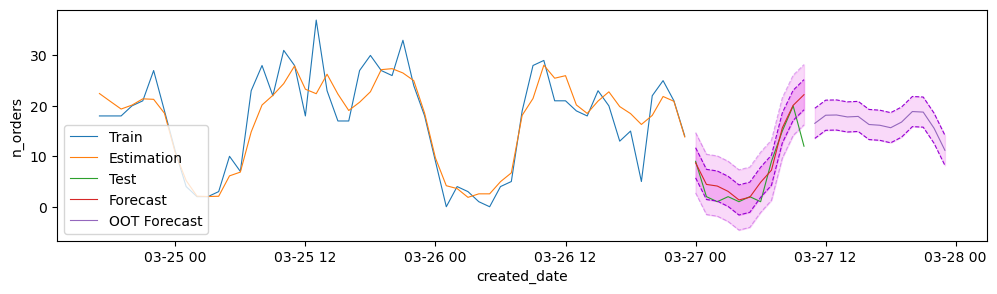

Processing account_id: d639773a-df2c-421e-ac87-6918a754572f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1631.661
train MAE:  479.531
test RMSE: 1019.718
test MAE:  430.248


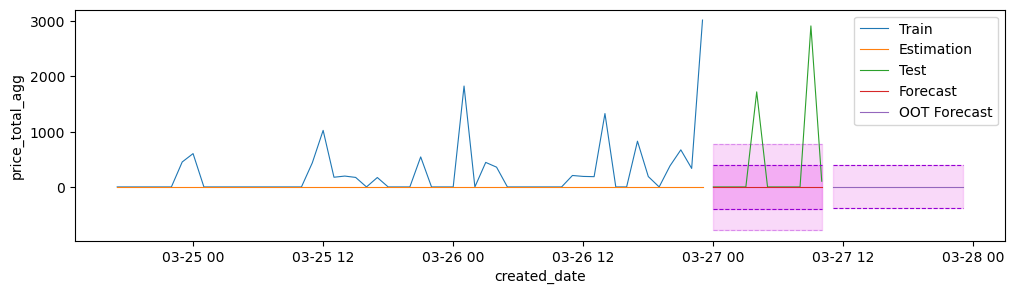

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 10.518
train MAE:  2.377
test RMSE: 1.000
test MAE:  0.455


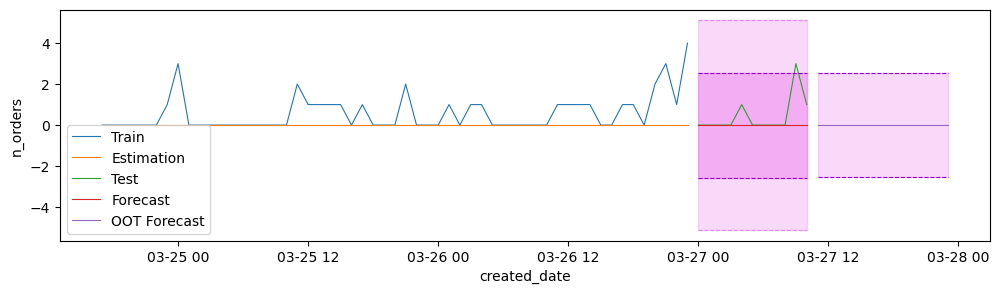

Processing account_id: 22fde42e-45d7-46cd-9d6f-3a4dbabbc579, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 571.638
train MAE:  228.619
test RMSE: 200.986
test MAE:  125.783


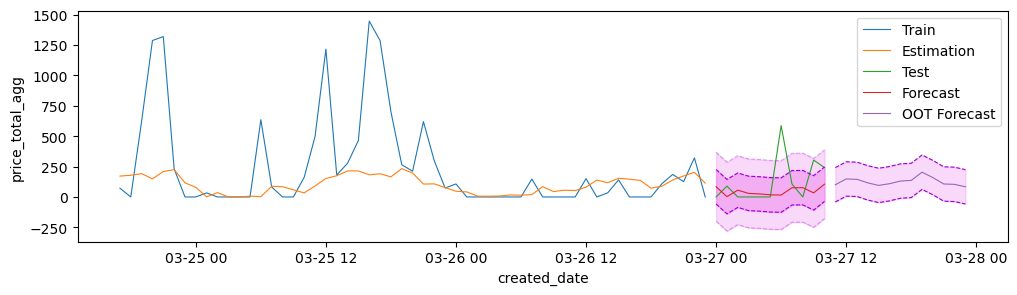

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.744
train MAE:  1.218
test RMSE: 0.993
test MAE:  0.762


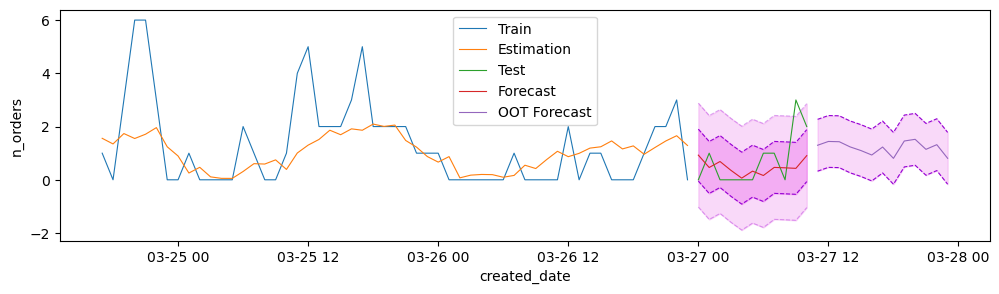

Processing account_id: 9d39683a-47b3-4a18-942d-f1d741a47e8c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 8266.050
train MAE:  2805.948
test RMSE: 14626.162
test MAE:  8546.495


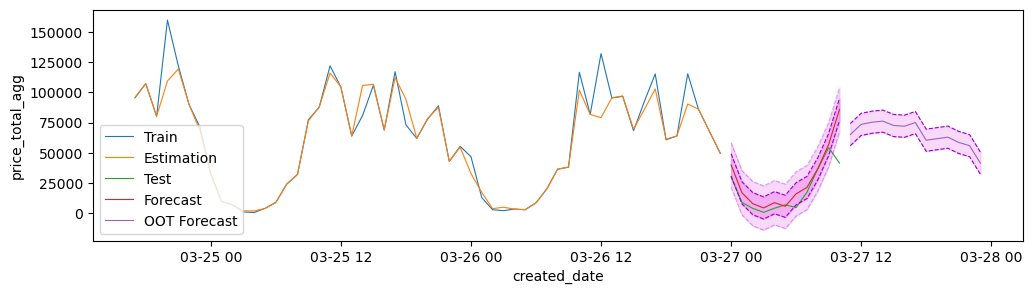

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 11.277
train MAE:  6.571
test RMSE: 15.011
test MAE:  9.054


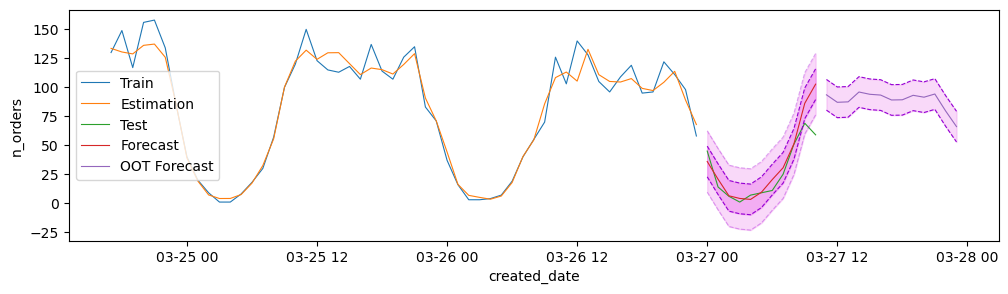

Processing account_id: aabe992c-cfad-4049-b5df-36c41f900a67, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 247.535
train MAE:  87.074
test RMSE: 115.882
test MAE:  58.770


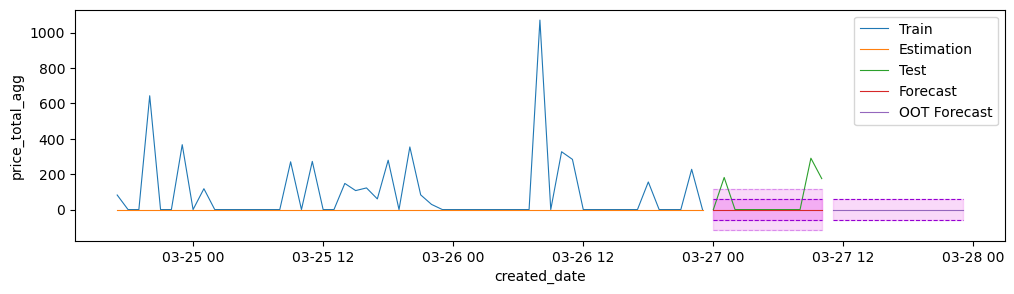

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.833
train MAE:  0.397
test RMSE: 0.522
test MAE:  0.273


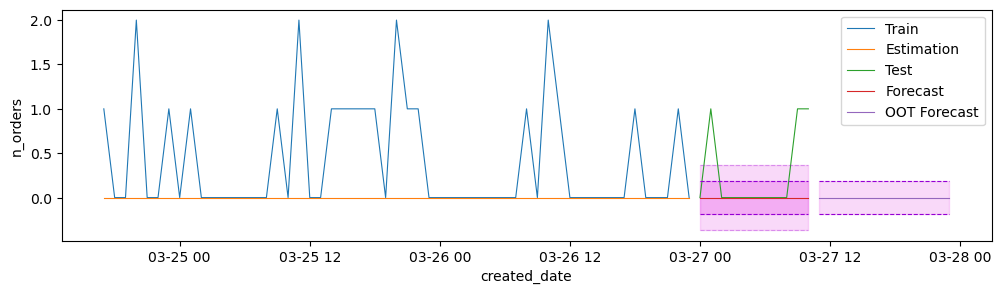

Processing account_id: f4471620-212b-4991-98d3-b498835d0c29, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


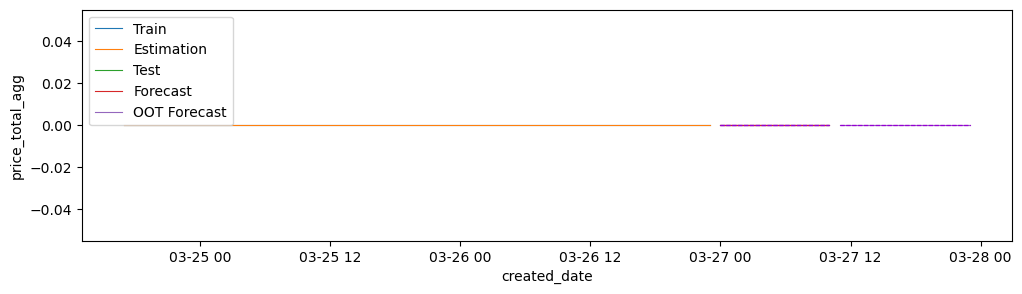

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.000
train MAE:  0.000
test RMSE: 0.000
test MAE:  0.000


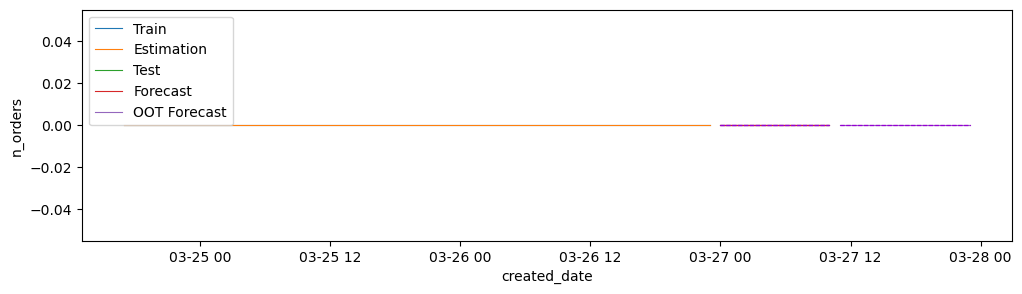

Processing account_id: adc6fb62-09e7-44fd-a619-f787ecfd140b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 694.781
train MAE:  443.142
test RMSE: 612.596
test MAE:  462.674


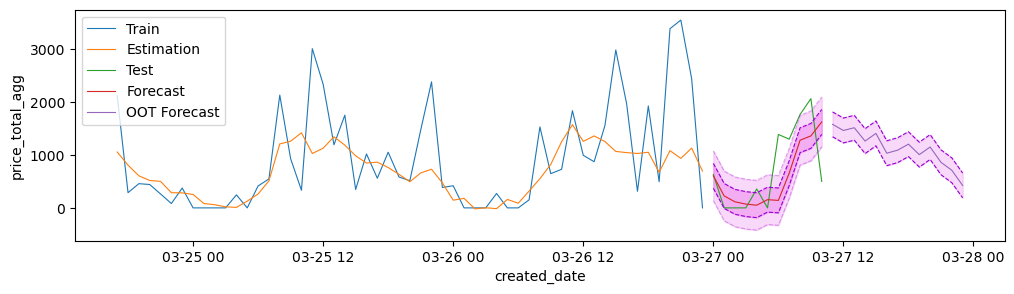

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.104
train MAE:  1.408
test RMSE: 2.092
test MAE:  1.387


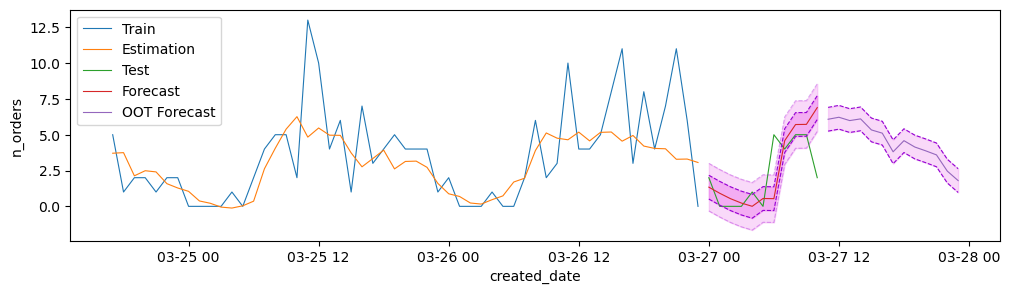

Processing account_id: 2058f680-aace-4b31-aed4-f34397b75096, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.307
train MAE:  0.036
test RMSE: 0.000
test MAE:  0.000


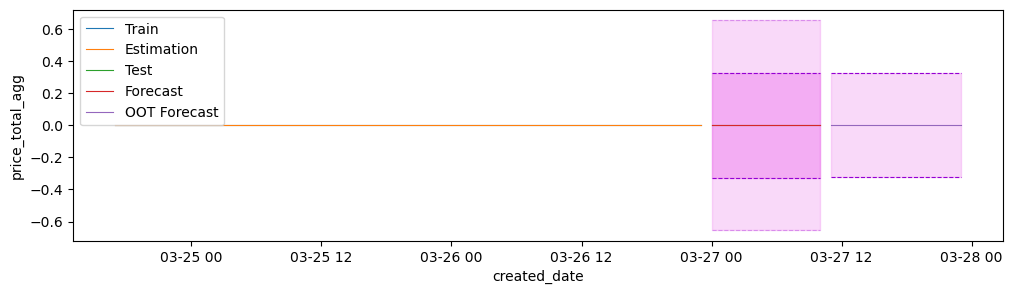

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 0.031
train MAE:  0.001
test RMSE: 0.000
test MAE:  0.000


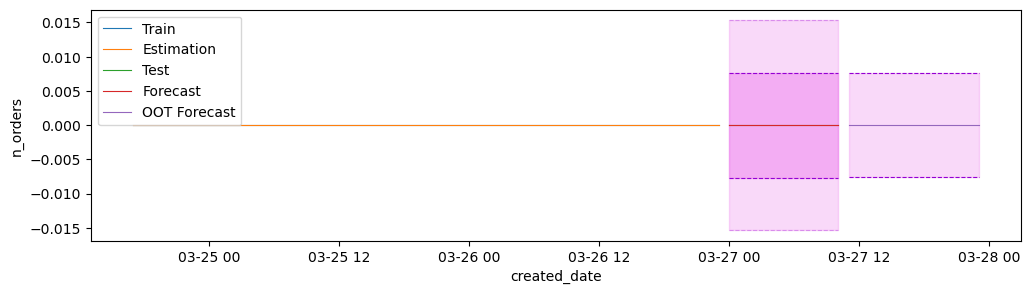

Processing account_id: 05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 12151.160
train MAE:  6668.480
test RMSE: 3002.995
test MAE:  1933.740


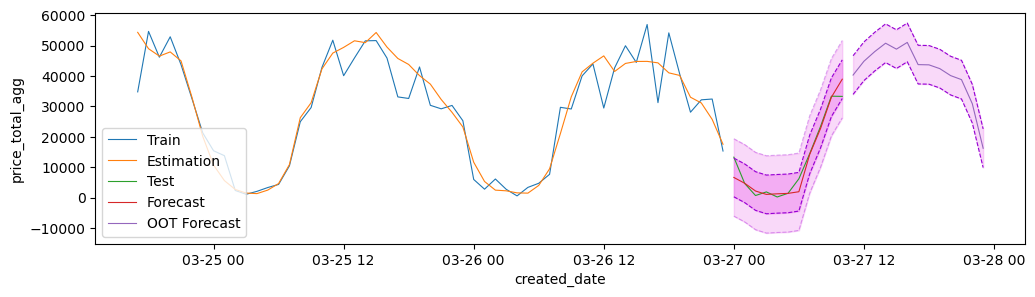

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 33.464
train MAE:  14.502
test RMSE: 6.220
test MAE:  4.784


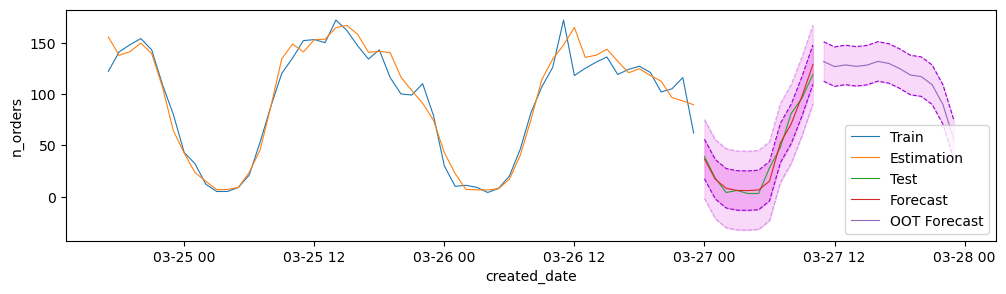

Processing account_id: 0ad2f65b-ee0e-4d50-93e2-84b76282325f, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 4499.061
train MAE:  2711.196
test RMSE: 1763.328
test MAE:  1042.009


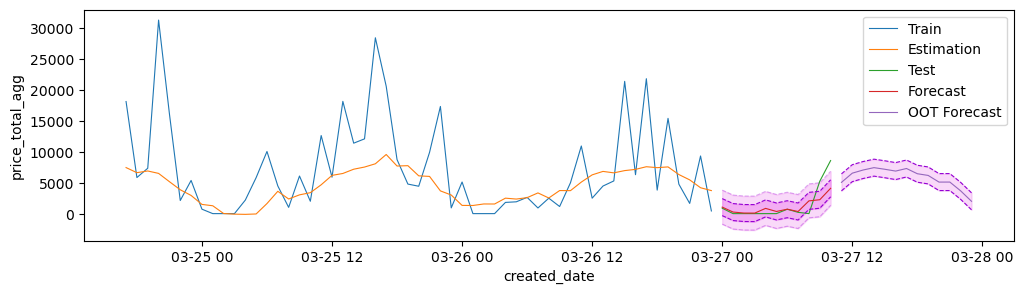

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.698
train MAE:  1.741
test RMSE: 1.087
test MAE:  0.664


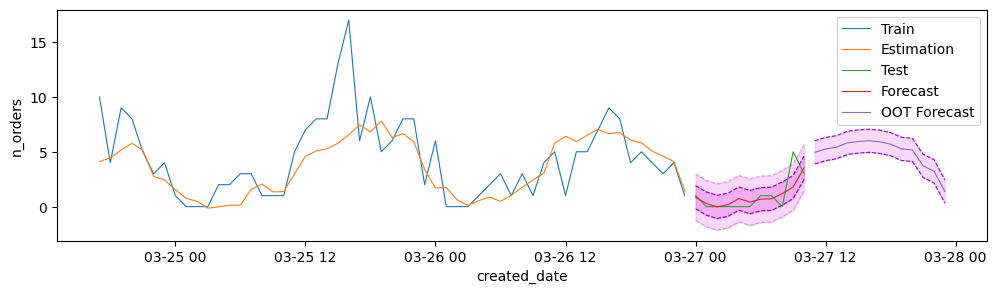

Processing account_id: bfcbb283-4e53-41fd-9b31-aa818f7f23ce, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1301.872
train MAE:  308.096
test RMSE: 375.657
test MAE:  201.455


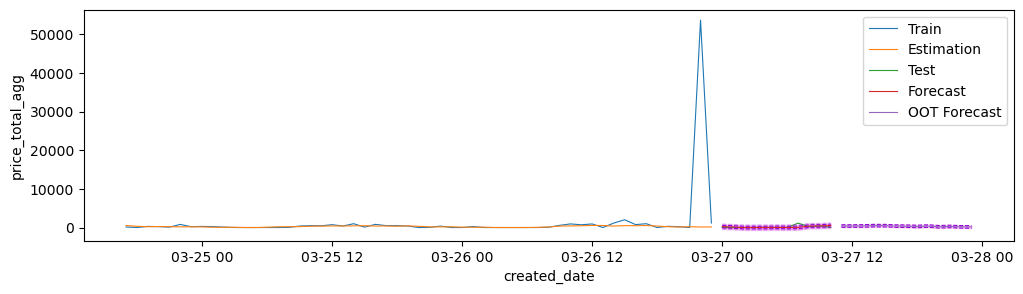

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.514
train MAE:  0.999
test RMSE: 1.170
test MAE:  0.865


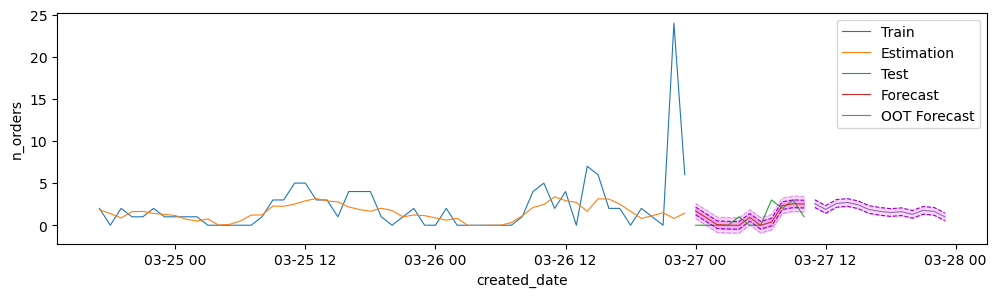

Processing account_id: 7db6eaca-fe22-41d7-bfb8-1fdde880feb8, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1314.792
train MAE:  222.389
test RMSE: 130.096
test MAE:  94.920


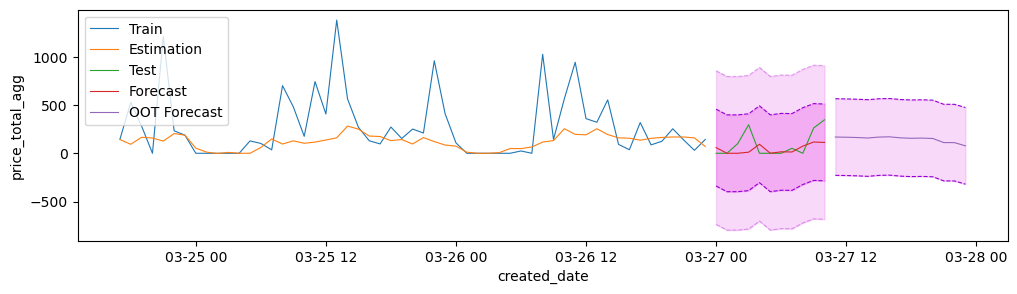

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.171
train MAE:  1.022
test RMSE: 0.953
test MAE:  0.796


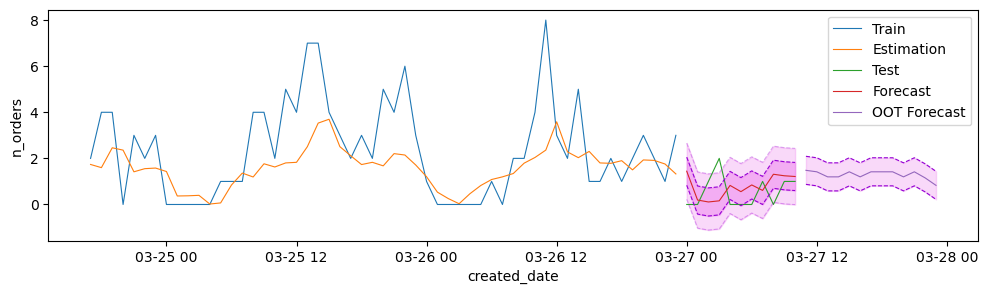

Processing account_id: 92f116fe-5818-41db-9eb5-87445ad3818e, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 632.127
train MAE:  389.381
test RMSE: 743.856
test MAE:  553.932


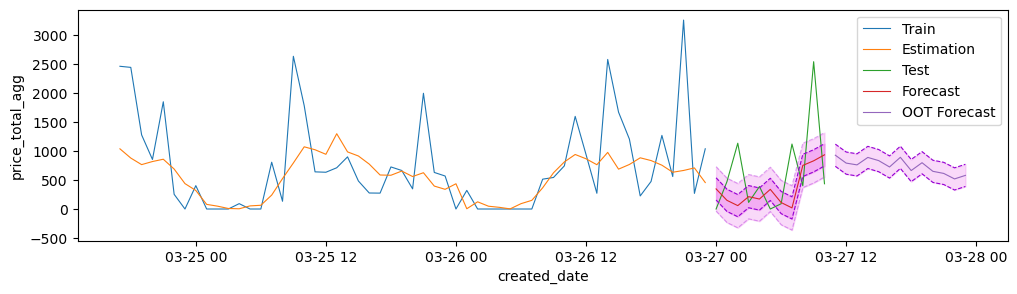

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.516
train MAE:  1.015
test RMSE: 1.010
test MAE:  0.886


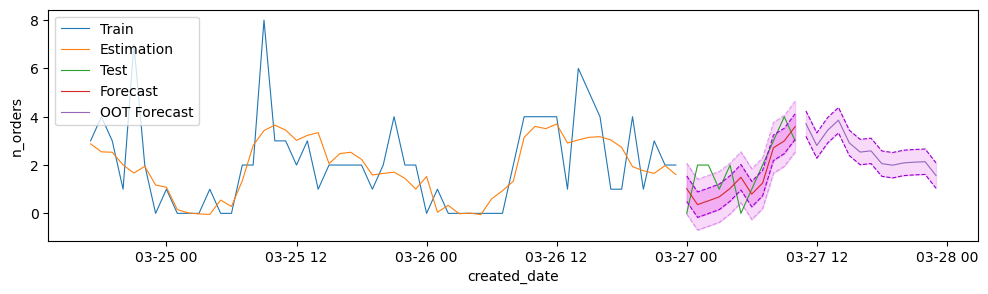

Processing account_id: b009c05b-326e-4ebe-988c-8d2229ec3a4c, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 913.463
train MAE:  552.796
test RMSE: 293.074
test MAE:  251.871


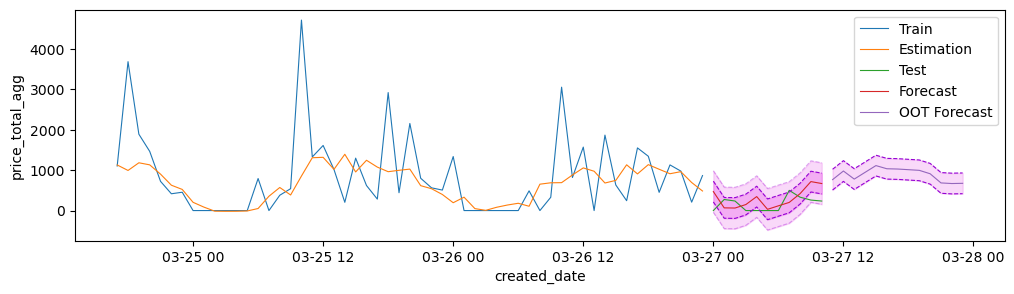

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 1.788
train MAE:  1.165
test RMSE: 0.832
test MAE:  0.637


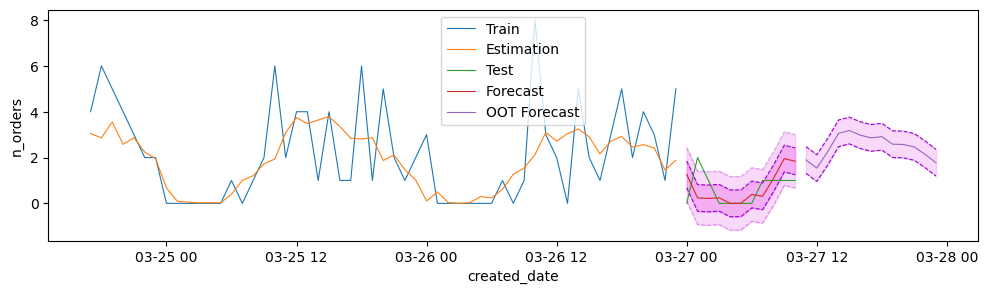

Processing account_id: 478cd985-f4fc-45b4-ac71-bf78cf11e07b, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 673.560
train MAE:  445.989
test RMSE: 0.128
test MAE:  0.128


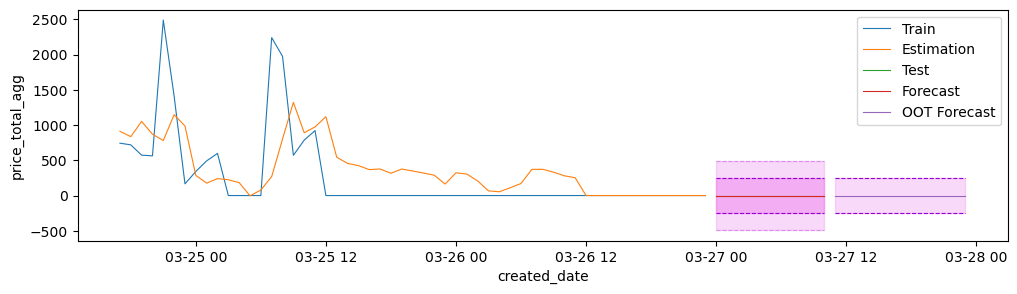

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 3.135
train MAE:  2.007
test RMSE: 0.040
test MAE:  0.040


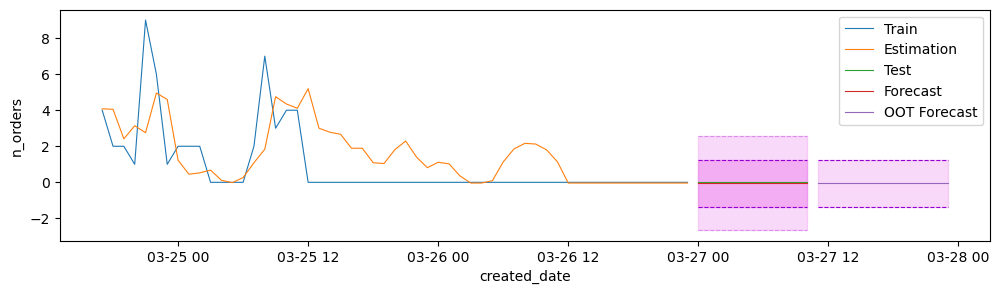

Processing account_id: 74abffac-6542-4eff-8eae-cc85463a5d02, sales_channel_id: ALL
Processing column: price_total_agg
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 914.850
train MAE:  608.343
test RMSE: 874.012
test MAE:  659.240


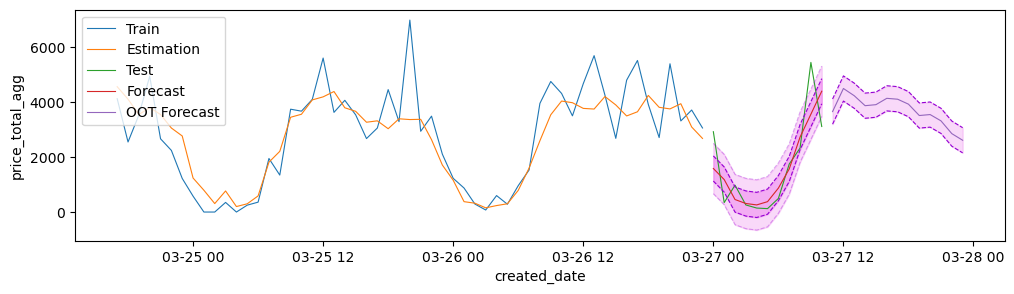

Processing column: n_orders
Fitting 5 folds for each of 75 candidates, totalling 375 fits
Fitting 5 folds for each of 75 candidates, totalling 375 fits
train RMSE: 2.625
train MAE:  1.180
test RMSE: 4.341
test MAE:  3.191


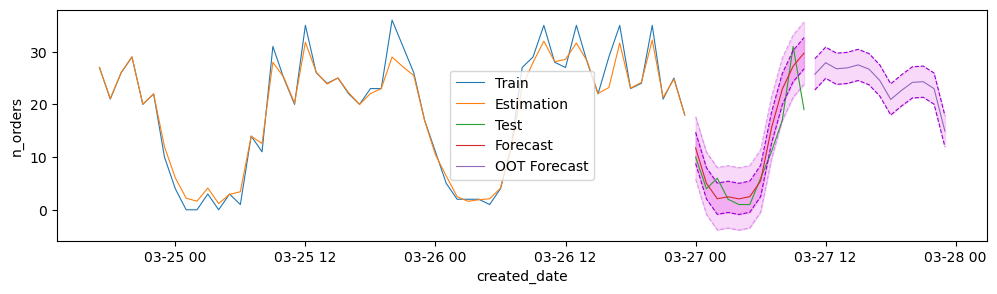

In [8]:
def preprocess_sales_data(account_id, sales_channel_id):
    if sales_channel_id == 'ALL':
        cond = (sales['account_id'] == account_id) & \
               (sales['status'].notna())
    else:
        cond = (sales['account_id'] == account_id) & \
               (sales['sales_channel_id'] == sales_channel_id) & \
               (sales['status'].notna())
    df_client = sales[cond].drop(['account_id', 'sales_channel_id'], axis=1)
    df_client['created_date'] = pd.to_datetime(df_client['created_date'], format='%Y-%m-%d %H:%M:%S.%f %z')
    df_client = df_client.sort_values('created_date').reset_index(drop=True)
    df_client['created_date'] = df_client['created_date'].dt.strftime("%Y-%m-%d %H:00:00").reset_index(drop=True)

    df_client_mod = df_client.groupby('created_date').agg(
        price_total_agg=('price_total', 'sum'),
        n_orders=('created_date', 'count')
    )
    df_client_mod.index = pd.to_datetime(df_client_mod.index, format='%Y-%m-%d %H:00:00')

    end_date = pd.to_datetime(END_DATE, format='%Y-%m-%d %H:%M:%S')
    start_date = end_date - relativedelta(months=LOOKBACK)
    date_index = pd.Series(pd.date_range(start=start_date, end=end_date, freq='h', name='created_date'))
    df_client_mod = pd.merge(date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    oot_date_index = pd.Series(df_oot.index, name='created_date')
    combined_date_index = pd.concat([date_index, oot_date_index], axis=0)
    df_client_mod = pd.merge(combined_date_index, df_client_mod, how='left', on='created_date').set_index('created_date')

    return df_client_mod


def create_lagged_features(df, lags=24):
    lagged_features = [df.shift(l).rename(f'lag_{l}') for l in range(1, lags + 1)]
    df_lag = pd.concat([df, pd.concat(lagged_features, axis=1)], axis=1).dropna().asfreq('h')
    return df_lag


def split_data(df_lag):
    df_train = df_lag.loc[df_lag.index < START_DATE].copy()
    df_test = df_lag.loc[(df_lag.index >= START_DATE) & (df_lag.index <= END_DATE)].copy()
    df_oot = df_lag.loc[df_lag.index > END_DATE].copy()
    return df_train, df_test, df_oot


def train_and_forecast(df_train, df_test, df_full, df_oot, col):
    X_train, y_train = df_train.drop(col, axis=1), df_train[col]
    X_test = df_test.drop(col, axis=1)
    X_full, y_full = df_full.drop(col, axis=1), df_full[col]
    X_oot = df_oot.drop(col, axis=1)
    
    train_mad = y_train.std()
    mad = y_full.std()
    
    gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                        param_grid={'max_depth': [1, 2, 4, 8, 16],
                                    'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                    'max_features': ['sqrt', 'log2', None]},
                        scoring='neg_mean_absolute_error',
                        cv=TimeSeriesSplit(),
                        n_jobs=-1,
                        verbose=1)
    gscv.fit(X_train, y_train)
    model = gscv.best_estimator_
    
    estimations = pd.Series(model.predict(X_train), index=X_train.index)

    forecast = pd.Series(model.predict(X_test), index=X_test.index)
    forecast_lower = forecast - CRIT_VALUE*train_mad
    forecast_upper = forecast + CRIT_VALUE*train_mad

    oot_gscv = GridSearchCV(GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=42, n_iter_no_change=3),
                            param_grid={'max_depth': [1, 2, 4, 8, 16],
                                        'subsample': [0.2, 0.4, 0.6, 0.8, 1],
                                        'max_features': ['sqrt', 'log2', None]},
                            scoring='neg_mean_absolute_error',
                            cv=TimeSeriesSplit(),
                            n_jobs=-1,
                            verbose=1)
    oot_gscv.fit(X_full, y_full)
    oot_model = gscv.best_estimator_
    
    oot_forecast_ls = []
    oot_forecast_lower_ls = []
    oot_forecast_upper_ls = []
    for i in range(len(X_oot)):
        x_oot = X_oot.iloc[i].to_frame().T
        
        x_oot_forecast = oot_model.predict(x_oot)[0]
        oot_forecast_ls.append(x_oot_forecast)
        oot_forecast_lower_ls.append(x_oot_forecast - CRIT_VALUE*mad)
        oot_forecast_upper_ls.append(x_oot_forecast + CRIT_VALUE*mad)
        
        for j, k in list(zip(range(i+1, len(X_oot)), range(len(X_oot)-i-1))):
            X_oot.iloc[j, k] = x_oot_forecast
            
    oot_forecast = pd.Series(oot_forecast_ls, index=X_oot.index)
    oot_forecast_lower = pd.Series(oot_forecast_lower_ls, index=X_oot.index)
    oot_forecast_upper = pd.Series(oot_forecast_upper_ls, index=X_oot.index)

    return {
        'estimations': estimations,
        'forecast': forecast,
        'forecast_lower': forecast_lower,
        'forecast_upper': forecast_upper,
        'oot_forecast': oot_forecast,
        'oot_forecast_lower': oot_forecast_lower,
        'oot_forecast_upper': oot_forecast_upper
    }
    
    
def compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col):
    y_train = df_train[col]
    y_test = df_test[col]
    estimations = forecast_results['estimations']
    forecast = forecast_results['forecast']
    forecast_lower = forecast_results['forecast_lower']
    forecast_upper = forecast_results['forecast_upper']
    oot_forecast = forecast_results['oot_forecast']
    oot_forecast_lower = forecast_results['oot_forecast_lower']
    oot_forecast_upper = forecast_results['oot_forecast_upper']
    
    train_mae = mean_absolute_error(df_train[col], estimations)
    train_rmse = root_mean_squared_error(df_train[col], estimations)
    print(f"train RMSE: {train_rmse:.3f}")
    print(f"train MAE:  {train_mae:.3f}")
    test_mae = mean_absolute_error(df_test[col], forecast)
    test_rmse = root_mean_squared_error(df_test[col], forecast)
    print(f"test RMSE: {test_rmse:.3f}")
    print(f"test MAE:  {test_mae:.3f}")
    
    plt.figure(figsize=(12, 3))
    sns.lineplot(y_train.iloc[-5*TEST_SIZE:], lw=0.8, label='Train')
    sns.lineplot(estimations.iloc[-5*TEST_SIZE:], lw=0.8, label='Estimation')
    sns.lineplot(y_test, lw=0.8, label='Test')
    sns.lineplot(forecast, lw=0.8, label='Forecast')
    sns.lineplot(forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_lower-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(2*forecast_upper-forecast, c='darkviolet', alpha=0.3, linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast, lw=0.8, label='OOT Forecast')
    sns.lineplot(oot_forecast_lower, c='darkviolet', linestyle='--', lw=0.8)
    sns.lineplot(oot_forecast_upper, c='darkviolet', linestyle='--', lw=0.8)
    plt.fill_between(x=forecast.index,
                     y1=forecast_lower,
                     y2=forecast_upper,
                     color='violet',
                     alpha=0.5)
    plt.fill_between(x=forecast.index,
                     y1=2*forecast_lower-forecast,
                     y2=2*forecast_upper-forecast,
                     color='violet',
                     alpha=0.3)
    plt.fill_between(x=oot_forecast.index,
                     y1=oot_forecast_lower,
                     y2=oot_forecast_upper,
                     color='violet',
                     alpha=0.3)
    plt.savefig(f'plots/machine_learning/forecast_{account_id}_{sales_channel_id}_{col}_ml.png')
    plt.legend()
    plt.show()
    
    return train_rmse, test_rmse, train_mae, test_mae


def save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict):
    with open(f'sql/time_series/forecast_{account_id}_{sales_channel_id}_ts.sql', 'w') as output_file:
        for i in range(len(df_test)):
            start_time = df_test.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['forecast'].iloc[i]});
                """
            )
        for i in range(len(df_oot)):
            start_time = df_oot.index[i]
            end_time = start_time + pd.Timedelta(hours=1)
            output_file.write(
                f"""
                INSERT INTO forecast (id, created, modified, platform, store_name, "start", "end",
                                      channel, seller, account_id, organization_id, store_id, minutes_interval,
                                      model, orders_high, orders_low, orders_mean, sales_high, sales_low, sales_mean)
                VALUES (gen_random_uuid(), now(), now(), 1, (select vtexid from vtex_account where id = '{account_id}'::uuid), '{start_time}', '{end_time}',
                        {sales_channel_id}, 'ALL', '{account_id}'::uuid, (select organizationid from vtex_account where id = '{account_id}'::uuid), NULL, 60, 'TBATS',
                        {forecast_dict['dataset_1']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_1']['oot_forecast'].iloc[i]},
                        {forecast_dict['dataset_0']['oot_forecast_upper'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast_lower'].iloc[i]}, {forecast_dict['dataset_0']['oot_forecast'].iloc[i]});
                """
            )


# Main
if ALL_SALES_CHANNELS:
    id_pairs = set(list(zip(df_count['account_id'], ['ALL']*len(df_count))))
else:
    id_pairs = list(zip(df_count['account_id'], df_count['sales_channel_id']))

summary_dict = {}
for account_id, sales_channel_id in id_pairs:
    print(f'Processing account_id: {account_id}, sales_channel_id: {sales_channel_id}')
    summary_dict[(account_id, sales_channel_id)] = {}

    df_client_mod = preprocess_sales_data(account_id, sales_channel_id)
    df_client_mod.fillna(0, inplace=True)

    forecast_dict = {}
    for n, col in enumerate(['price_total_agg', 'n_orders']):
        print(f'Processing column: {col}')
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}'] = {'name': col}

        df_lag = create_lagged_features(df_client_mod[col])
        df_train, df_test, df_oot = split_data(df_lag)
        df_full = pd.concat([df_train, df_test], axis=0)

        forecast_results = train_and_forecast(df_train, df_test, df_full, df_oot, col)
        
        forecast_dict[f'dataset_{n}'] = {}
        forecast_dict[f'dataset_{n}'].update(forecast_results)
        
        train_rmse, test_rmse, train_mae, test_mae = compute_metrics_and_plot_time_series(forecast_results, df_train, df_test, col)
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train RMSE'] = train_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test RMSE'] = test_rmse
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['train MAE'] = train_mae
        summary_dict[(account_id, sales_channel_id)][f'dataset_{n}']['test MAE'] = test_mae

    save_forecast_to_sql(account_id, sales_channel_id, df_test, df_oot, forecast_dict)

In [9]:
dataset_0 = pd.DataFrame({k: v['dataset_0'] for k, v in summary_dict.items()}).T
dataset_1 = pd.DataFrame({k: v['dataset_1'] for k, v in summary_dict.items()}).T

In [10]:
summary = (
    pd
    .concat([dataset_0, dataset_1], axis=0)
    .rename({'name': 'dataset'}, axis=1)
    .sort_index()
    .reset_index(names=['account_id', 'sales_channel_id'])
)
summary.to_csv('summary_ml.csv', sep=';')

summary

,account_id,sales_channel_id,dataset,train RMSE,test RMSE,train MAE,test MAE
0,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,price_total_agg,12151.160256,3002.994547,6668.479946,1933.740425
1,05d9cc3a-decc-4fa2-b4e8-b44eef40e3b6,ALL,n_orders,33.464112,6.220145,14.501812,4.78445
2,0661e926-f219-456e-bde5-612fee6f891c,ALL,price_total_agg,1103.821973,333.049067,389.891434,251.684237
3,0661e926-f219-456e-bde5-612fee6f891c,ALL,n_orders,6.901343,1.173281,1.722596,0.962112
4,0ad2f65b-ee0e-4d50-93e2-84b76282325f,ALL,price_total_agg,4499.060931,1763.327949,2711.196396,1042.009143
...,...,...,...,...,...,...,...
69,e2de40dd-743b-4105-9077-3f343fea980d,ALL,n_orders,5.177887,2.580652,3.112539,2.171226
70,f4471620-212b-4991-98d3-b498835d0c29,ALL,price_total_agg,0.0,0.0,0.0,0.0
71,f4471620-212b-4991-98d3-b498835d0c29,ALL,n_orders,0.0,0.0,0.0,0.0
72,f9129295-bb08-4330-b60c-9f0beadda521,ALL,price_total_agg,78843.397471,36095.278813,30375.911099,30902.685538


In [11]:
train_metrics = summary.groupby('dataset')['train MAE'].mean()

train_metrics

dataset
n_orders              2.557802
price_total_agg    1557.274021
Name: train MAE, dtype: object

In [12]:
test_metrics = summary.groupby('dataset')['test MAE'].mean()

test_metrics

dataset
n_orders              1.435622
price_total_agg    1506.240361
Name: test MAE, dtype: object

In [13]:
(train_metrics - test_metrics).abs()

dataset
n_orders            1.12218
price_total_agg    51.03366
dtype: object